## Code-Struktur

Der gesamte Maschinenraum liegt im Paket [`tep/`](tep) und wird von allen
TEP-Notebooks geteilt. Dieses Notebook enthält nur noch, was es von
seinen Geschwistern unterscheidet: die Konfiguration und die Aufrufe.

| Modul | Inhalt |
|---|---|
| `tep/core.py` | Spaltennamen, Splits, Cutoffs, Vorverarbeitung, lineare Algebra — geteilt mit `tep.tsfresh` |
| `tep/plotting.py` | Confusion-Matrix-Darstellung, ebenfalls geteilt |
| `tep/eigen/config.py` | `SpectrumConfig` — alle Stellschrauben |
| `tep/eigen/data.py` | Trainings-CSVs lesen und zusammenführen |
| `tep/eigen/spectra.py` | Registry der Verfahren: `pca`, `dyca`, `dpca`, `cva`, `ica`, `lda` |
| `tep/eigen/aggregate.py` | Mittelwert/Std je Fehlerklasse, CSV-Export |
| `tep/eigen/plots.py` | die vier Standardplots |
| `tep/eigen/classify.py` | Klassifikation auf den exportierten Spektren |

Ein Verfahren ist ein `Spectrum` mit vier Angaben: Spaltenpräfix,
Klartextname, CSV-Stamm und die Rechnung selbst. Ein eigenes Verfahren
kommt über `tep.eigen.register(...)` dazu, ohne dass hier etwas
angefasst werden muss.

> Die Rechnungen sind zeilengetreu aus der früheren Notebook-Fassung
> übernommen — alle sechs Verfahren wurden vor dem Umbau als
> **bitidentisch** nachgewiesen, ebenso die Spaltennamen und die
> Export-Dateinamen. Die vorhandenen `*_eigenvalues_train*.csv` bleiben
> damit gültig.

## Code-Struktur

Der gesamte Maschinenraum liegt im Paket [`tep/`](tep) und wird von allen
TEP-Notebooks geteilt. Dieses Notebook enthält nur noch, was es von
seinen Geschwistern unterscheidet: die Konfiguration und die Aufrufe.

| Modul | Inhalt |
|---|---|
| `tep/core.py` | Spaltennamen, Splits, Cutoffs, Vorverarbeitung, lineare Algebra — geteilt mit `tep.tsfresh` |
| `tep/plotting.py` | Confusion-Matrix-Darstellung, ebenfalls geteilt |
| `tep/eigen/config.py` | `SpectrumConfig` — alle Stellschrauben |
| `tep/eigen/data.py` | Trainings-CSVs lesen und zusammenführen |
| `tep/eigen/spectra.py` | Registry der Verfahren: `pca`, `dyca`, `dpca`, `cva`, `ica`, `lda` |
| `tep/eigen/aggregate.py` | Mittelwert/Std je Fehlerklasse, CSV-Export |
| `tep/eigen/plots.py` | die vier Standardplots |
| `tep/eigen/classify.py` | Klassifikation auf den exportierten Spektren |

Ein Verfahren ist ein `Spectrum` mit vier Angaben: Spaltenpräfix,
Klartextname, CSV-Stamm und die Rechnung selbst. Ein eigenes Verfahren
kommt über `tep.eigen.register(...)` dazu, ohne dass hier etwas
angefasst werden muss.

> Die Rechnungen sind zeilengetreu aus der früheren Notebook-Fassung
> übernommen — alle sechs Verfahren wurden vor dem Umbau als
> **bitidentisch** nachgewiesen, ebenso die Spaltennamen und die
> Export-Dateinamen. Die vorhandenen `*_eigenvalues_train*.csv` bleiben
> damit gültig.


In [1]:
# ============================================================
# Imports - der gemeinsame Unterbau steckt im Paket tep
# ============================================================
# Wird tep/**.py bearbeitet, muss der Kernel neu gestartet werden;
# alternativ die beiden autoreload-Zeilen aktivieren.
# %load_ext autoreload
# %autoreload 2
import numpy as np
import pandas as pd

from tep.eigen import (SpectrumConfig, aggregate, export, fit_scaler,
                       load_train, merge_faults, run_spectra, versions)
from tep.eigen import plot_bars, plot_cv, plot_means, plot_stds

print(versions())

tsfresh 0.21.2 | pandas 3.0.3 | numpy 2.4.6 | sklearn 1.9.0 | Kerne: 8


In [2]:
# ============================================================
# Konfiguration - die EINZIGE Stelle, an der geschraubt wird
# ============================================================
# Alle nicht gesetzten Felder stehen auf den Defaults aus
# tep/eigen/config.py (pre_fault_cutoff=21, k_bar=10,
# plot_mode='linear', ...).
# runs_per_fault=3 kuerzt auf drei Laeufe je Fault - ein
# Probelauf von Minuten statt Stunden.

CFG = SpectrumConfig(
    method="pca",
    scaling_mode="scaler",

    # Linienplots zeigen die ersten k_max Komponenten von 52.
    k_max=25,
)

## Rohdaten laden

Beide Trainings-CSVs werden **einmal** gelesen und zu einem DataFrame zusammengeführt. Der Pre-Fault-Bereich wird erst in der Spektren-Schleife verworfen (`CFG.pre_fault_cutoff = 21`): der Fehler wird 1 h nach Simulationsstart injiziert, bei 3-min-Sampling sind das 20 Samples Vorlauf. Ohne diesen Schnitt würden die ersten 20 Normalbetriebs-Samples die Fault-Statistik verwässern.

In [3]:
# ============================================================
# Rohdaten laden
# ============================================================
# Beide Trainings-CSVs muessen im Arbeitsverzeichnis liegen. Sie werden
# EINMAL gelesen und zu einem DataFrame (Fault 0..20) zusammengefuehrt;
# die Spektren-Schleife gruppiert daraus nach (fault, run).
df_ff, df_faulty = load_train(CFG)
df_all = merge_faults(df_ff, df_faulty)

# Scaler nur fitten, wenn er auch gebraucht wird (liest 250k Zeilen).
scaler = fit_scaler(CFG)

  lese TEP_FaultFree_Training.csv ...
  lese TEP_Faulty_Training.csv ...
  FaultFree_Training: (250000, 55)
  Faulty_Training   : (5000000, 55)
  Prozessvariablen  : 52
  kombiniert: (5250000, 55), Faults [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
Fitte StandardScaler auf TEP_FaultFree_Training (Normalbetrieb) ...
  fertig.


## Spektrum je Lauf

Pro (faultNumber, simulationRun) eine Zerlegung. Das Ergebnis ist eine Zeile je Lauf mit den Werten als Spalten — genau die Form, die auch als CSV exportiert wird.

In [4]:
# ============================================================
# Spektrum je (Fault, Run)
# ============================================================
# Der teure Teil: eine Zerlegung pro Run. Runs, an denen das Verfahren
# numerisch scheitert oder die zu kurz sind, werden gezaehlt und
# uebersprungen - die Meldung darunter sagt wie viele.
per_run = run_spectra(CFG, df_all, scaler=scaler)

per_run.head()

Berechne PCA-Spektrum pro Run:   0%|          | 0/10500 [00:00<?, ?it/s]

Erfolgreiche Runs: 10500


,faultNumber,simulationRun,lambda_1,lambda_2,lambda_3,lambda_4,lambda_5,lambda_6,lambda_7,lambda_8,...,lambda_43,lambda_44,lambda_45,lambda_46,lambda_47,lambda_48,lambda_49,lambda_50,lambda_51,lambda_52
0,0,1,0.116983,0.079319,0.059423,0.049929,0.048594,0.041325,0.038161,0.032043,...,0.000940,0.000810,0.000270,0.000158,0.000092,0.000071,0.000030,0.000002,9.963311e-10,9.348905e-10
1,0,2,0.238902,0.156864,0.045795,0.037832,0.034227,0.030665,0.029453,0.025921,...,0.000705,0.000598,0.000226,0.000133,0.000070,0.000046,0.000024,0.000001,7.012619e-10,6.465875e-10
2,0,3,0.224297,0.109782,0.045995,0.042281,0.038110,0.036324,0.035677,0.033611,...,0.000867,0.000585,0.000209,0.000120,0.000071,0.000057,0.000022,0.000001,7.629493e-10,6.857716e-10
3,0,4,0.126083,0.101541,0.066122,0.048129,0.040485,0.040061,0.036580,0.034172,...,0.001029,0.000804,0.000270,0.000173,0.000090,0.000061,0.000029,0.000002,8.783341e-10,8.105147e-10
4,0,5,0.178816,0.071893,0.050950,0.044708,0.042764,0.040102,0.034002,0.032561,...,0.000927,0.000706,0.000263,0.000155,0.000084,0.000060,0.000028,0.000001,8.617937e-10,8.549860e-10


## Aggregation je Fehlerklasse

Über die 500 Läufe einer Fehlerklasse gemittelt, mit Standardabweichung. pandas rechnet mit `ddof=1` (Stichproben-Std), passend für N = 500.

In [5]:
# ============================================================
# Aggregation: Mittelwert und Standardabweichung je Fehlerklasse
# ============================================================
# Aus einer Zeile je (Fault, Run) wird eine Zeile je Fault mit
# <praefix>i_mean und <praefix>i_std.
agg = aggregate(CFG, per_run)

agg.head()

Aggregierte PCA-Statistiken pro Fault: (21, 105)


,faultNumber,lambda_1_mean,lambda_1_std,lambda_2_mean,lambda_2_std,lambda_3_mean,lambda_3_std,lambda_4_mean,lambda_4_std,lambda_5_mean,...,lambda_48_mean,lambda_48_std,lambda_49_mean,lambda_49_std,lambda_50_mean,lambda_50_std,lambda_51_mean,lambda_51_std,lambda_52_mean,lambda_52_std
0,0,0.160924,0.040081,0.090754,0.022668,0.053609,0.004604,0.045072,0.003816,0.041691,...,0.000060,6.677992e-06,0.000028,3.123743e-06,1.659851e-06,4.125501e-07,8.696761e-10,8.640568e-11,7.761482e-10,7.985250e-11
1,1,0.412927,0.018537,0.276142,0.023336,0.140207,0.015839,0.046999,0.003947,0.024822,...,0.000008,1.198828e-06,0.000004,5.424356e-07,9.071559e-07,1.437281e-07,1.179534e-10,1.583492e-11,1.054131e-10,1.421730e-11
2,2,0.711174,0.009776,0.161303,0.004372,0.027052,0.005680,0.013371,0.003693,0.008892,...,0.000007,4.920161e-07,0.000003,2.191755e-07,3.677731e-07,7.944511e-08,1.000421e-10,5.337838e-12,8.914346e-11,4.707367e-12
3,3,0.164746,0.040800,0.092673,0.023313,0.053630,0.004757,0.044816,0.003851,0.041432,...,0.000059,6.769858e-06,0.000027,3.123703e-06,1.656771e-06,4.177611e-07,8.545170e-10,9.139124e-11,7.649525e-10,8.255956e-11
4,4,0.165192,0.040939,0.093013,0.023323,0.054067,0.004890,0.044934,0.003871,0.041517,...,0.000059,6.777686e-06,0.000027,3.160175e-06,1.657490e-06,4.179512e-07,8.557371e-10,8.993430e-11,7.633614e-10,7.981912e-11


## Visualisierung

Drei Blickwinkel auf dieselbe Aggregattabelle: das mittlere Niveau, seine Streuung über die Läufe und die dimensionslose relative Streuung. Dazu die ersten Komponenten als Balken mit der Fault-0-Referenz — dort ist am schnellsten zu sehen, welche Komponenten der Fehler wirklich verschiebt.

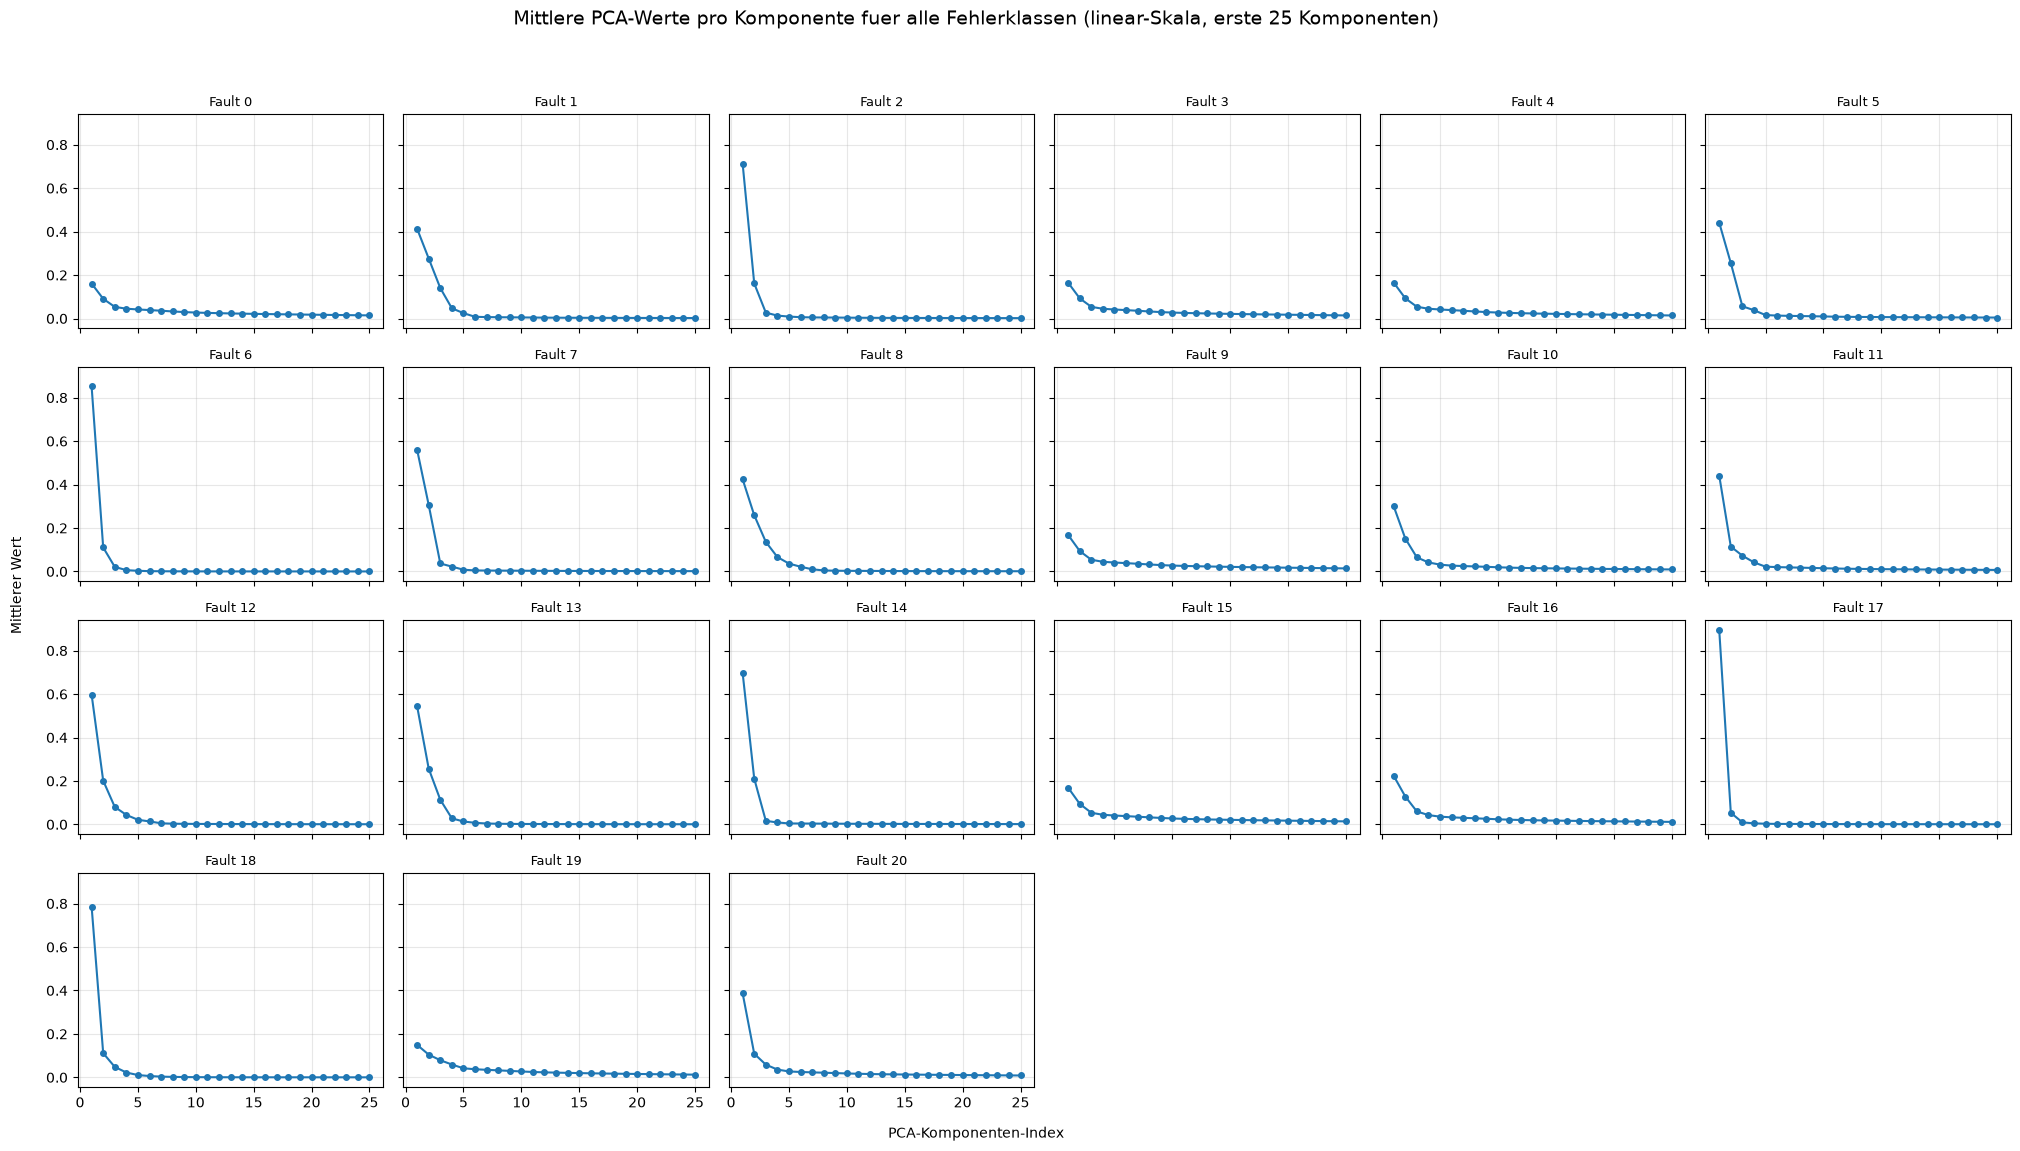

In [6]:
# ============================================================
# Mittleres Spektrum je Fehlerklasse
# ============================================================
# Ein Subplot je Fehlerklasse. Die Darstellungsart steuert
# CFG.plot_mode ("linear" | "log" | "relative"), die Zahl der
# gezeigten Komponenten CFG.k_max.
_ = plot_means(CFG, agg)

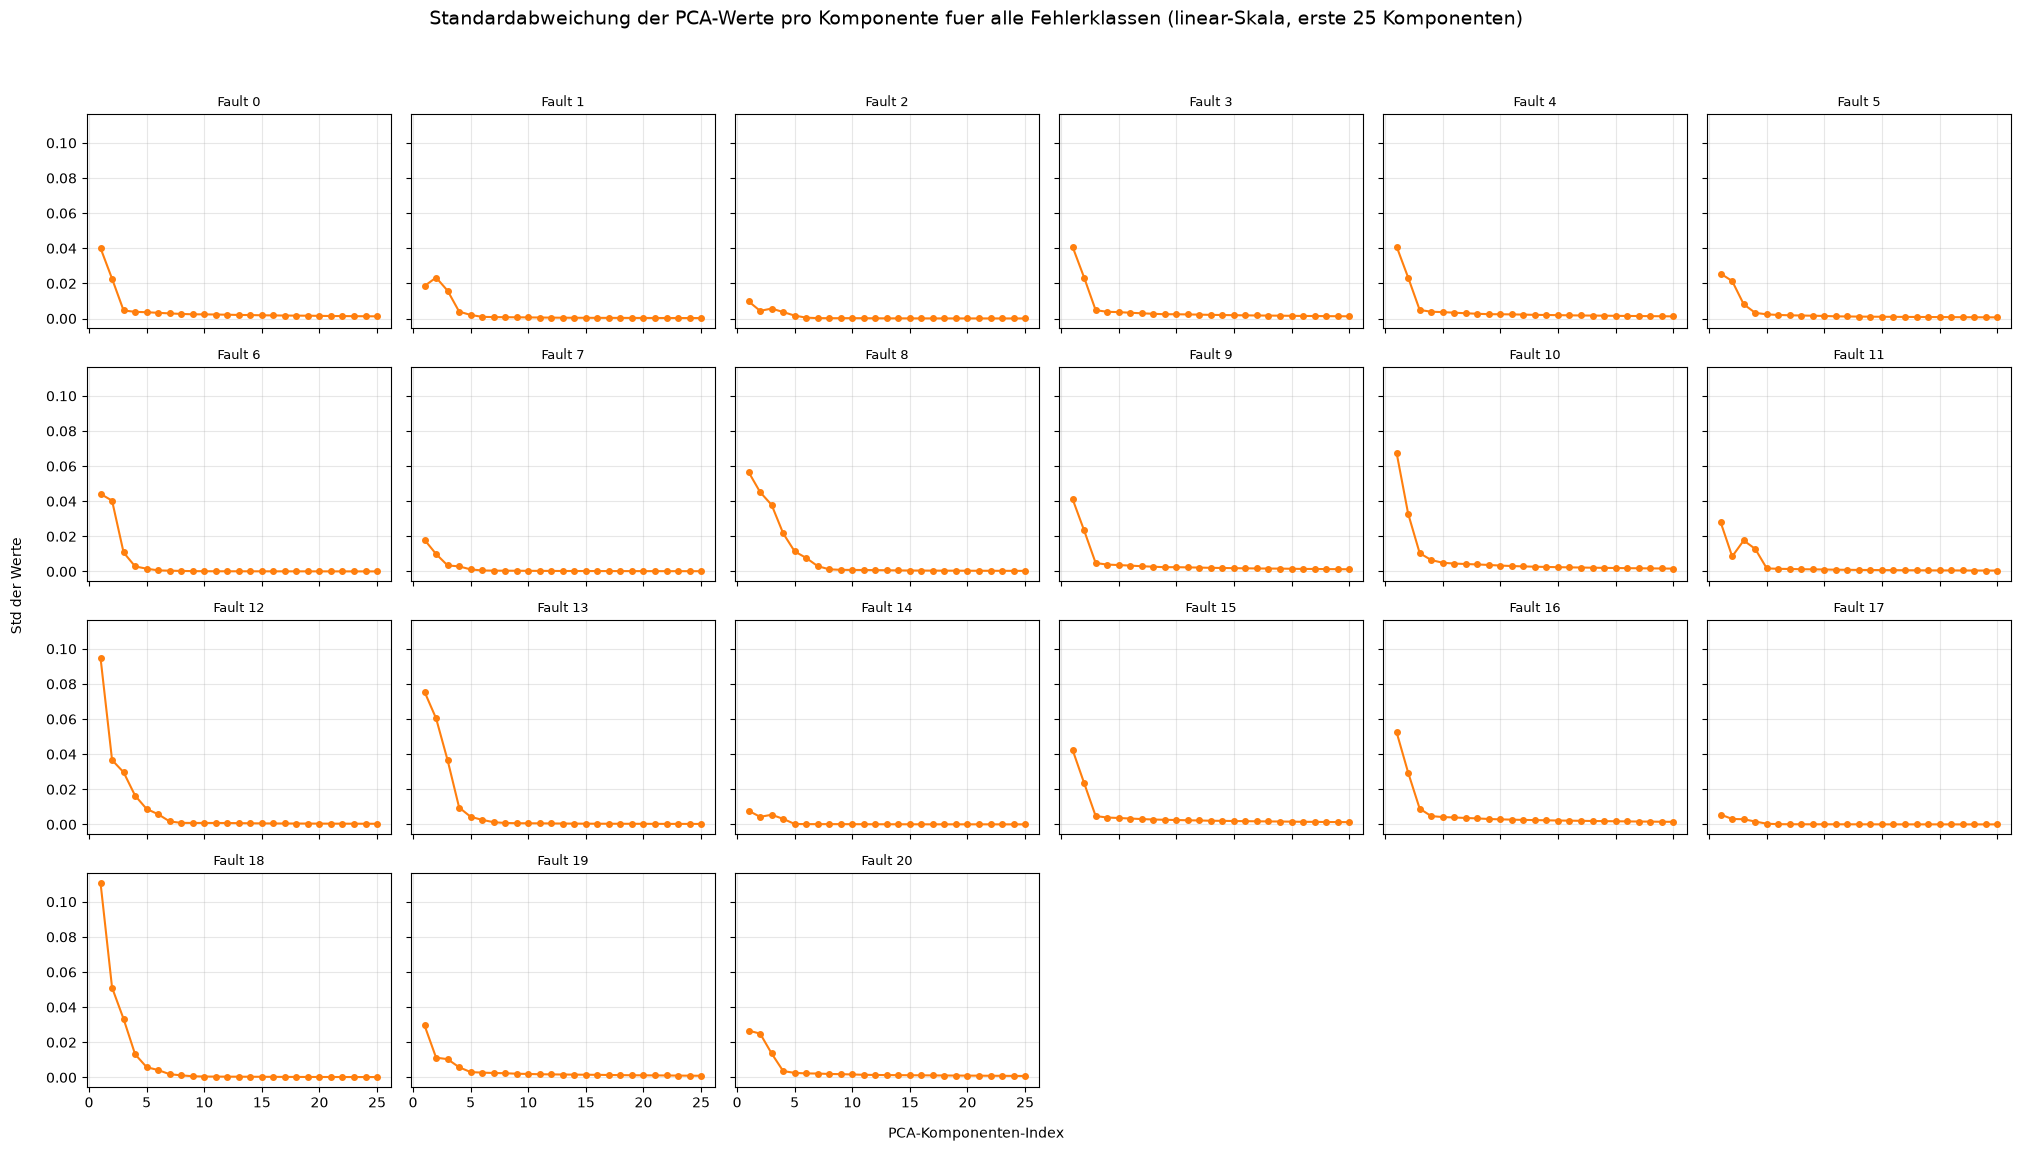

In [7]:
# ============================================================
# Standardabweichung je Komponente
# ============================================================
# Struktur identisch zum Mittelwertsplot. Eine breite Streuung heisst,
# dass die Komponente ueber die Runs einer Klasse nicht stabil ist.
_ = plot_stds(CFG, agg)

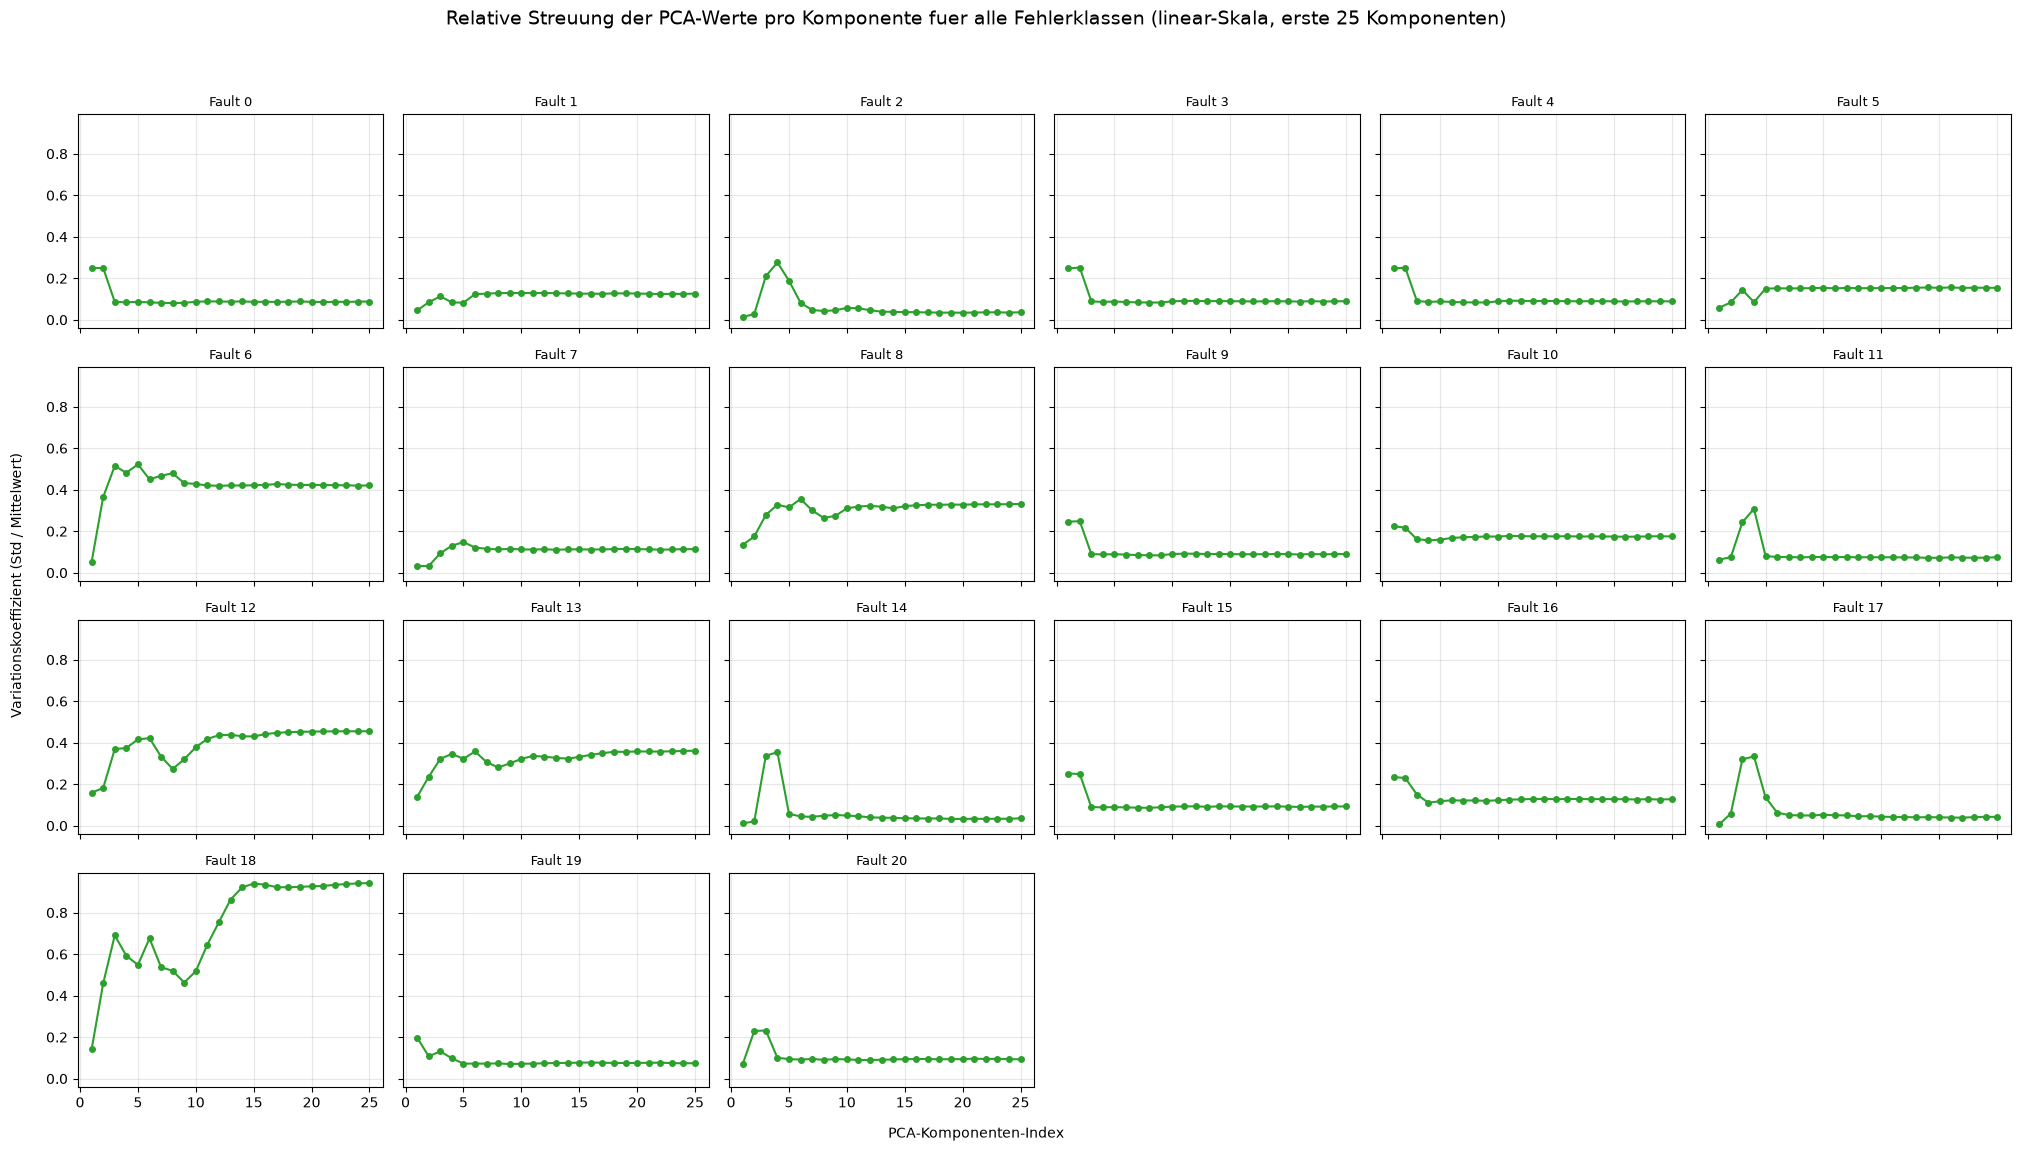

In [8]:
# ============================================================
# Relative Streuung: Variationskoeffizient CV = Std / Mittelwert
# ============================================================
# Dimensionslos und damit ueber Komponenten hinweg vergleichbar, deren
# Absolutniveau um Groessenordnungen auseinanderliegt. Eigener
# Darstellungsmodus: CFG.plot_mode_cv.
_ = plot_cv(CFG, agg)

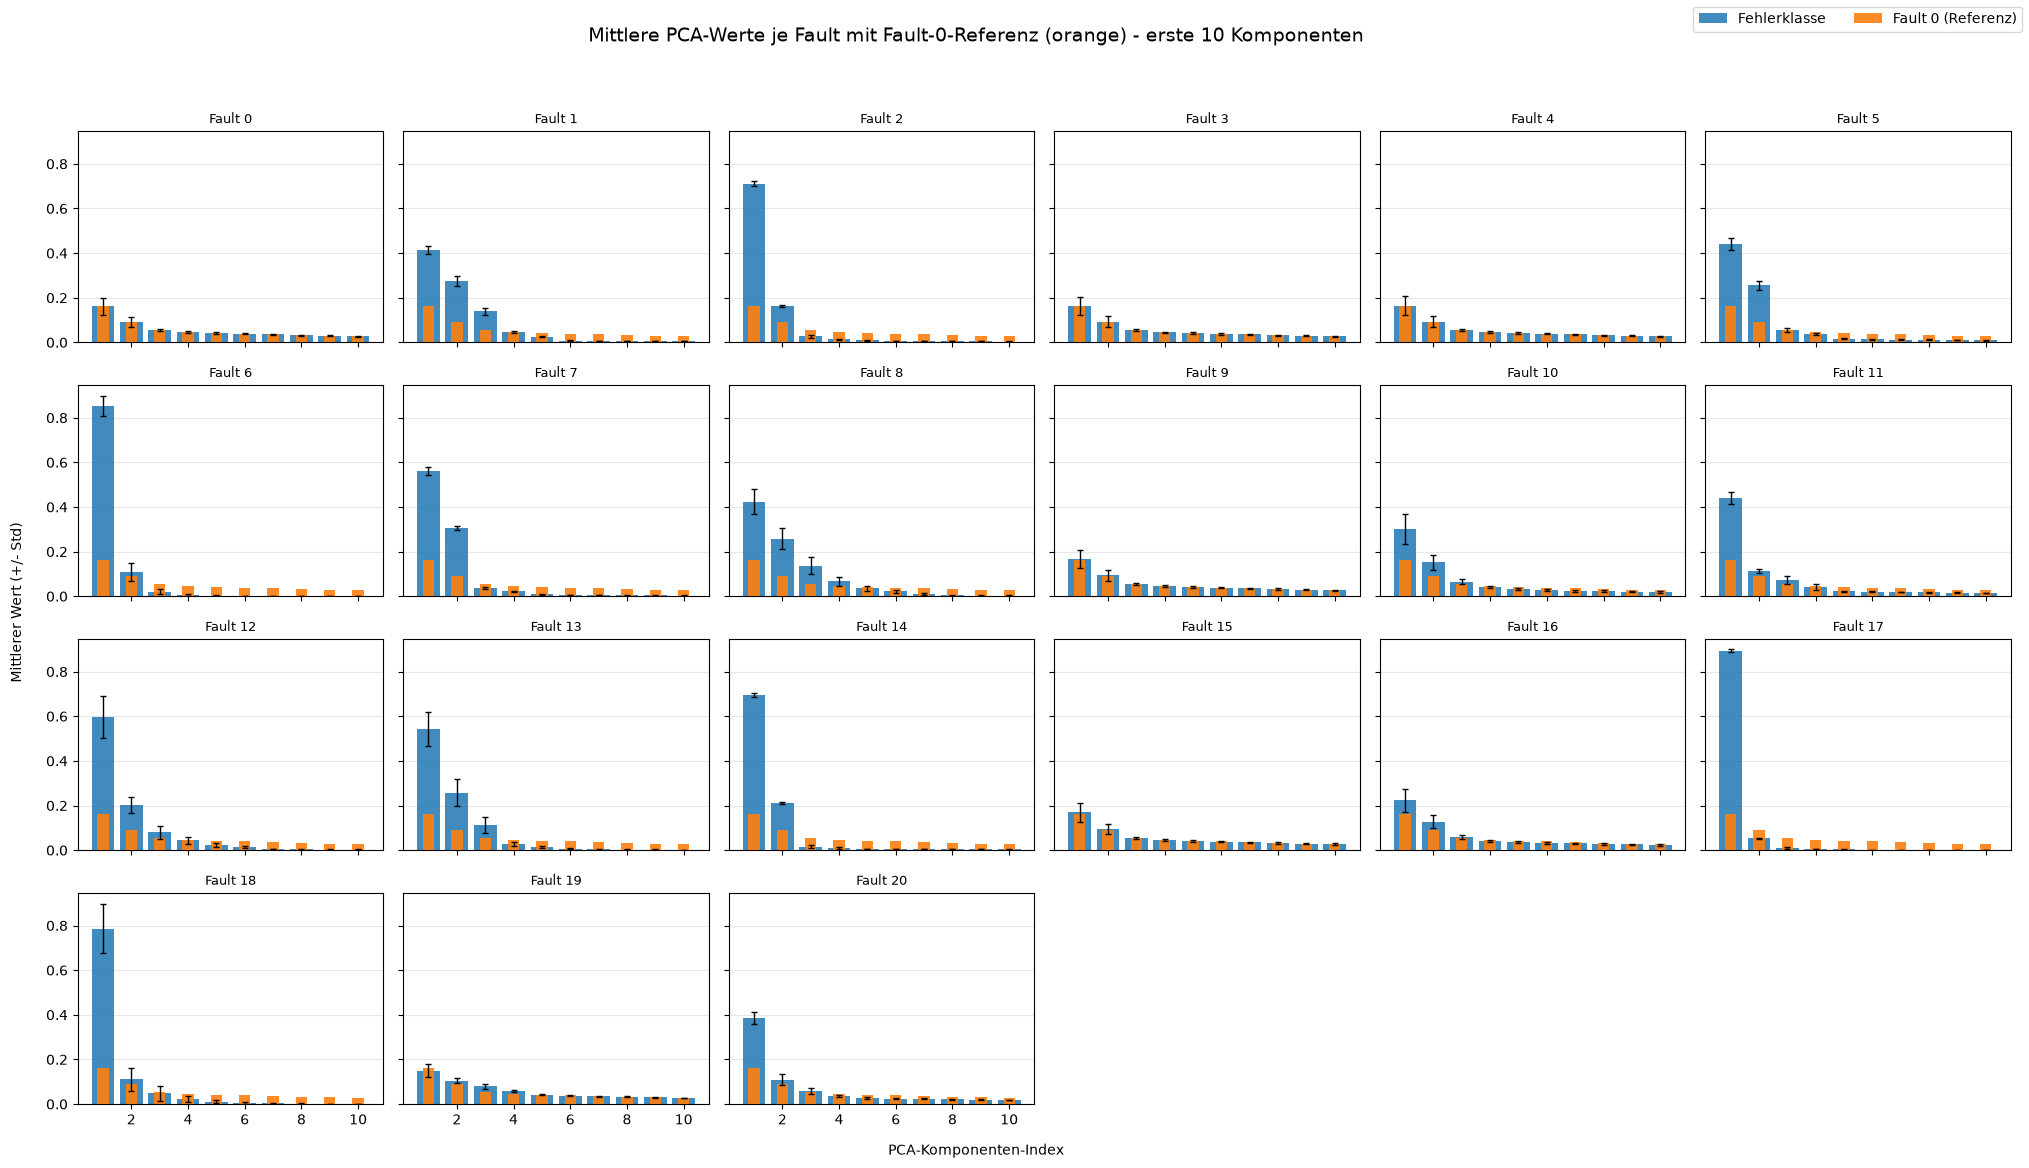

In [9]:
# ============================================================
# Erste k Werte je Fehlerklasse mit Fault-0-Referenz
# ============================================================
# Der schmale orange Balken ist Fault 0 - so ist auf einen Blick zu
# sehen, welche Komponenten sich unter dem Fehler wirklich verschieben.
# Zahl der Balken: CFG.k_bar.
_ = plot_bars(CFG, agg)

## Export der Trainings-Spektren

Schreibt `pca_eigenvalues_train_scaler.csv` neben das Notebook. `LazyClassifier_PCA_DyCA.ipynb` liest diese Datei — der Name ist deshalb eingefroren.

In [10]:
# ============================================================
# Export der Trainings-Spektren
# ============================================================
# Stellt sie fuer LazyClassifier_PCA_DyCA.ipynb bereit. Die TEST-Spektren
# werden bewusst NICHT hier berechnet, sondern dort - dieses Notebook
# bleibt training-only. Der Dateiname enthaelt den Skalierungsmodus, ein
# Umschalten ueberschreibt also nichts.
export(CFG, per_run)

PCA-Train gespeichert: (10500, 54) -> .\pca_eigenvalues_train_scaler.csv


'.\\pca_eigenvalues_train_scaler.csv'